In [3]:
%pip install tensorflow

   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/331.9 MB 4.2 MB/s eta 0:01:19
   ---------------------------------------- 2.6/331.9 MB 8.9 MB/s eta 0:00:37
   ---------------------------------------- 3.1/331.9 MB 6.0 MB/s eta 0:00:56
    --------------------------------------- 4.7/331.9 MB 6.3 MB/s eta 0:00:52
    --------------------------------------- 7.1/331.9 MB 7.5 MB/s eta 0:00:44
   - -------------------------------------- 8.4/331.9 MB 8.0 MB/s eta 0:00:41
   - -------------------------------------- 11.5/331.9 MB 8.4 MB/s eta 0:00:39
   - -------------------------------------- 13.4/331.9 MB 8.5 MB/s eta 0:00:38
   - -------------------------------------- 15.7/331.9 MB 8.8 MB/s eta 0:00:36
   -- ------------------------------------- 18.1/331.9 MB 9.2 MB/s eta 0:00:35
   -- ------------------------------------- 20.7/331.9 MB 9.5 MB/s eta 0:00:33
   -- ------------------------------------- 23.1/331.9 MB 9.6 MB/s

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.0 which is incompatible.


In [33]:
import tensorflow as tf
import os

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [21]:
base_dir = './Banana Ripeness Classification Dataset'

In [35]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'valid')
test_dir = os.path.join(base_dir, 'test')

In [37]:
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [39]:
print("Loading Training Data:")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224), 
    batch_size=32,
    class_mode='categorical'
)

Loading Training Data:
Found 11783 images belonging to 4 classes.


In [41]:
print("Loading Validation Data:")
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Loading Validation Data:
Found 1121 images belonging to 4 classes.


In [43]:
print("Loading Test Data:")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False # Keep it in order so we can check exactly which ones it gets wrong later
)

Loading Test Data:
Found 561 images belonging to 4 classes.


In [45]:
print("\nClasses found:", train_generator.class_indices)


Classes found: {'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}


In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax') 
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

F:\apps\New folder\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      44,302,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 44,398,148 (169.37 MB)

 Trainable params: 44,398,148 (169.37 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:

print("Starting training...")
history = model.fit(
    train_generator,
    epochs=10, 
    validation_data=val_generator
)
print("Training complete!")

Starting training...
Epoch 1/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 623s 2s/step - accuracy: 0.7417 - loss: 0.6879 - val_accuracy: 0.8742 - val_loss: 0.3530
Epoch 2/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 543s 1s/step - accuracy: 0.8875 - loss: 0.3177 - val_accuracy: 0.9054 - val_loss: 0.2896
Epoch 3/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 517s 1s/step - accuracy: 0.9148 - loss: 0.2433 - val_accuracy: 0.9340 - val_loss: 0.1803
Epoch 4/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 530s 1s/step - accuracy: 0.9285 - loss: 0.1971 - val_accuracy: 0.9179 - val_loss: 0.2679
Epoch 5/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 523s 1s/step - accuracy: 0.9469 - loss: 0.1514 - val_accuracy: 0.9652 - val_loss: 0.1513
Epoch 6/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.9658 - loss: 0.0986 - val_accuracy: 0.9572 - val_loss: 0.1538
Epoch 7/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 510s 1s/step - accuracy: 0.9644 - loss: 0.0946 - val_accuracy: 0.9634 - val_loss: 0.1399
Epoch 8/10
369/369 ━━━━━━━━━━━━━━━━━━━━ 978s 3s/step - accuracy: 0.9826 - lo

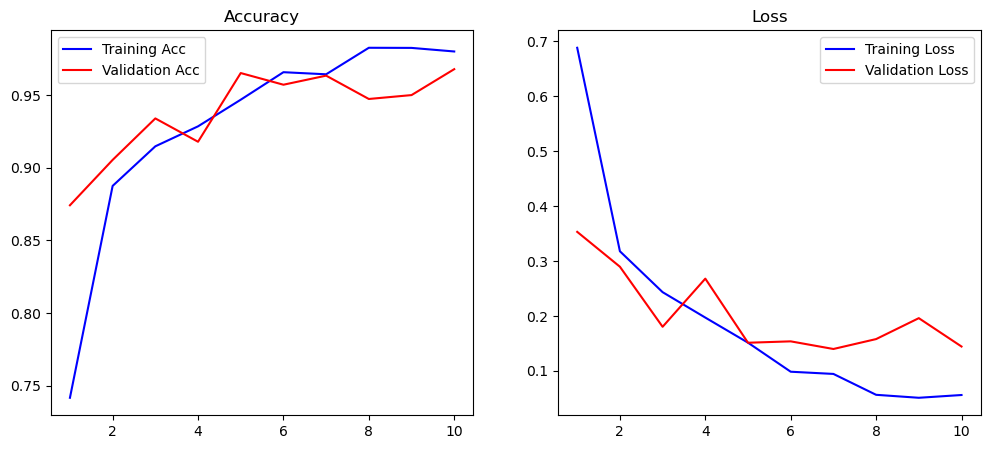

In [50]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training Acc')
plt.plot(epochs, val_acc, 'r', label='Validation Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, val_loss, 'r', label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [53]:
# Evaluate the model on the completely unseen Test Data
print("Taking the Final Exam on Test Data...")

test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nFinal Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Final Test Loss: {test_loss:.4f}")

Taking the Final Exam on Test Data...
18/18 ━━━━━━━━━━━━━━━━━━━━ 8s 425ms/step - accuracy: 0.9626 - loss: 0.1534

Final Test Accuracy: 96.26%
Final Test Loss: 0.1534


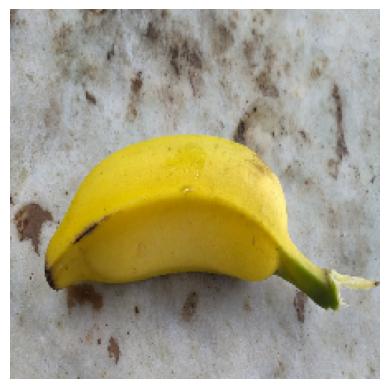

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step

AI Prediction: This banana is RIPE
Confidence Level: 89.45%


In [55]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = './data.jpg'

img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.axis('off')
plt.show()

# 4. Convert the image to numbers and normalize it
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add a batch dimension
img_array /= 255.0 # Normalize pixels like we did in training

# 5. Make the Prediction
predictions = model.predict(img_array)

# 6. Translate the math back into a readable label
class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[np.argmax(predictions)]
confidence = np.max(predictions) * 100

print(f"\nAI Prediction: This banana is {predicted_class.upper()}")
print(f"Confidence Level: {confidence:.2f}%")

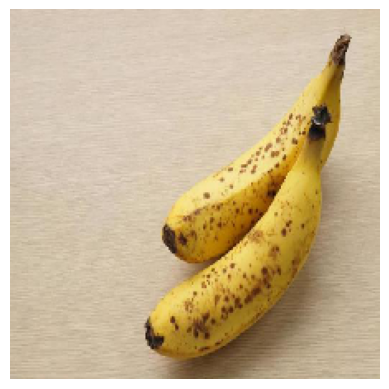

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step

AI Prediction: This banana is ROTTEN
Confidence Level: 99.63%


In [57]:
img_path = './data2.jpeg'

img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.axis('off')
plt.show()

# 4. Convert the image to numbers and normalize it
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) # Add a batch dimension
img_array /= 255.0 # Normalize pixels like we did in training

# 5. Make the Prediction
predictions = model.predict(img_array)

# 6. Translate the math back into a readable label
class_labels = list(train_generator.class_indices.keys())
predicted_class = class_labels[np.argmax(predictions)]
confidence = np.max(predictions) * 100

print(f"\nAI Prediction: This banana is {predicted_class.upper()}")
print(f"Confidence Level: {confidence:.2f}%")

In [59]:
model.save("my_cnn_model.h5")